<a href="https://colab.research.google.com/github/poonam-021/explainable-ai-stress-burnout/blob/main/models/Visual_Analysis_Of_Stress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CORE TRAINING PIPELINE

In [1]:
import os           # For navigating folders and file paths
import random       # Python's built-in random number generator

# --- Data & Math ---
import numpy as np          # Arrays, matrix math, pixel manipulation
import pandas as pd         # DataFrames — used heavily for CK+ CSV

# --- Image processing ---
import cv2                  # OpenCV: reading, resizing, colour conversion

# --- Visualisation ---
import matplotlib.pyplot as plt   # Plotting images, charts, curves
import matplotlib.patches as mpatches  # For custom legend patches
import seaborn as sns              # Beautiful statistical plots

# --- Progress bars (so long loops don't feel like they froze) ---
from tqdm import tqdm

# --- Path handling (cleaner than raw strings) ---
from pathlib import Path

# --- TensorFlow / Keras (our deep learning framework) ---
import tensorflow as tf
from tensorflow import keras

# --- Collections (for counting) ---
from collections import Counter

# ── Fix ALL random seeds so results are 100% reproducible ───
SEED = 42
random.seed(SEED)                          # Python random
np.random.seed(SEED)                       # NumPy random
tf.random.set_seed(SEED)                   # TensorFlow random
os.environ['PYTHONHASHSEED'] = str(SEED)   # Hash-based randomness in Python

# ── Print versions so we know our environment ───────────────
print("=" * 55)
print("  ✅  All imports loaded successfully!")
print("=" * 55)
print(f"  NumPy     : {np.__version__}")
print(f"  Pandas    : {pd.__version__}")
print(f"  OpenCV    : {cv2.__version__}")
print(f"  TensorFlow: {tf.__version__}")
print(f"  GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("=" * 55)
import os           # For navigating folders and file paths
import random       # Python's built-in random number generator

# --- Data & Math ---
import numpy as np          # Arrays, matrix math, pixel manipulation
import pandas as pd         # DataFrames — used heavily for CK+ CSV

# --- Image processing ---
import cv2                  # OpenCV: reading, resizing, colour conversion

# --- Visualisation ---
import matplotlib.pyplot as plt   # Plotting images, charts, curves
import matplotlib.patches as mpatches  # For custom legend patches
import seaborn as sns              # Beautiful statistical plots

# --- Progress bars (so long loops don't feel like they froze) ---
from tqdm import tqdm

# --- Path handling (cleaner than raw strings) ---
from pathlib import Path

# --- TensorFlow / Keras (our deep learning framework) ---
import tensorflow as tf
from tensorflow import keras

# --- Collections (for counting) ---
from collections import Counter

# ── Fix ALL random seeds so results are 100% reproducible ───
SEED = 42
random.seed(SEED)                          # Python random
np.random.seed(SEED)                       # NumPy random
tf.random.set_seed(SEED)                   # TensorFlow random
os.environ['PYTHONHASHSEED'] = str(SEED)   # Hash-based randomness in Python

print("=" * 55)
print("  ✅  All imports loaded successfully!")
print("=" * 55)
print(f"  NumPy     : {np.__version__}")
print(f"  Pandas    : {pd.__version__}")
print(f"  OpenCV    : {cv2.__version__}")
print(f"  TensorFlow: {tf.__version__}")
print(f"  GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("=" * 55)


  ✅  All imports loaded successfully!
  NumPy     : 2.0.2
  Pandas    : 2.2.2
  OpenCV    : 4.13.0
  TensorFlow: 2.19.0
  GPU available: False
  ✅  All imports loaded successfully!
  NumPy     : 2.0.2
  Pandas    : 2.2.2
  OpenCV    : 4.13.0
  TensorFlow: 2.19.0
  GPU available: False


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Copy zip from Drive to Colab's fast local disk
!cp /content/drive/MyDrive/raf-db.zip /content/

# Unzip quietly (-q) into a dedicated folder (-d)
!unzip -q /content/raf-db.zip -d /content/raf_data/

print("✅  RAF-DB extracted to /content/raf_data/")

✅  RAF-DB extracted to /content/raf_data/


In [4]:
!cp /content/drive/MyDrive/ck+.zip /content/
!unzip -q /content/ck+.zip -d /content/cf_data/

print("✅  CK+ extracted to /content/cf_data/")

✅  CK+ extracted to /content/cf_data/


In [5]:
#RAF-DB paths
RAF_TRAIN_DIR = Path('/content/raf_data/raf-db/train')  # 7 emotion folders
RAF_TEST_DIR  = Path('/content/raf_data/raf-db/test')   # same structure


In [6]:
#CK+ path
CK_CSV_PATH = Path('/content/cf_data/ck+/ckextended.csv')

In [7]:
# ── Target image size (EfficientNetV2-S expects 224×224×3) ───
IMG_SIZE = 224      # Both height and width
IMG_CHANNELS = 3    # RGB (3 colour channels)

In [8]:
STRESS    = 1       # Label for stressed images
NO_STRESS = 0       # Label for non-stressed images

In [9]:
#RAF-DB emotion label mapping
# Folder number (as a string) → emotion name → binary label
# We store the name too so our EDA prints are readable
RAF_EMOTION_NAMES = {
    '1': 'Surprise',   # → No-Stress
    '2': 'Fear',       # → Stress
    '3': 'Disgust',    # → Stress
    '4': 'Happy',      # → No-Stress
    '5': 'Sad',        # → Stress
    '6': 'Anger',      # → Stress
    '7': 'Neutral',    # → No-Stress
}

# Set of folder numbers that map to STRESS=1
RAF_STRESS_FOLDERS = {'2', '3', '5', '6'}   # Fear, Disgust, Sad, Anger


In [10]:
#CK+ emotion label mapping
# CK+ uses DIFFERENT numbers than RAF-DB
CK_EMOTION_NAMES = {
    0: 'Anger',      # → Stress
    1: 'Contempt',   # → Discard (ambiguous, not used)
    2: 'Disgust',    # → Stress
    3: 'Fear',       # → Stress
    4: 'Happy',      # → No-Stress
    5: 'Sadness',    # → Stress
    6: 'Surprise',   # → No-Stress
    7: 'Neutral',    # → No-Stress
}

# CK+ emotion integers that are stress-related
CK_STRESS_EMOTIONS = {0, 2, 3, 5}    # Anger, Disgust, Fear, Sadness


In [11]:
#Training constants
BATCH_SIZE    = 32     # Images per training step
EPOCHS_STAGE1 = 10     # Frozen backbone training
EPOCHS_STAGE2 = 20     # Fine-tuning training
LEARNING_RATE = 1e-3   # Initial learning rate

In [12]:
paths_to_check = {
    "RAF Train Dir" : RAF_TRAIN_DIR,
    "RAF Test Dir"  : RAF_TEST_DIR,
    "CK+ CSV"       : CK_CSV_PATH,
}

In [13]:
all_ok = True
for name, path in paths_to_check.items():
    exists = path.exists()
    status = "✅" if exists else "❌  NOT FOUND"
    print(f"  {status}  {name}: {path}")
    if not exists:
        all_ok = False

print("=" * 55)
if all_ok:
    print("  ✅  All paths verified. Ready to proceed!")
else:
    print("  ❌  Fix the missing paths above before continuing.")

  ✅  RAF Train Dir: /content/raf_data/raf-db/train
  ✅  RAF Test Dir: /content/raf_data/raf-db/test
  ✅  CK+ CSV: /content/cf_data/ck+/ckextended.csv
  ✅  All paths verified. Ready to proceed!


In [15]:
print("📊  EDA — RAF-DB DATASET ANALYSIS")

  📊  EDA — RAF-DB DATASET ANALYSIS


In [16]:
#We'll build a list of dicts, then make a DataFrame.
#it iterate through train/test splits, count images per emotion folder, maps them to emotion names and binary stress labels

#list to hold dictionaries.. one per folder/split combo
raf_stats = []

for split_name, split_dir in [("Train", RAF_TRAIN_DIR), ("Test", RAF_TEST_DIR)]:

    for folder_num in sorted(os.listdir(split_dir)):  # '1','2',...,'7' (sorted alphabetically)

        folder_path = split_dir / folder_num #builds a full path using '/'

        # Skip if it's not a folder (e.g., hidden files like .DS_Store)
        if not folder_path.is_dir():
            continue

        # Count only image files (jpg, jpeg, png — case insensitive)
        image_files = [
            f for f in folder_path.iterdir()
            if f.suffix.lower() in ['.jpg', '.jpeg', '.png']
        ]
        count = len(image_files)

        # Get emotion name from our mapping
        emotion_name = RAF_EMOTION_NAMES.get(folder_num, 'Unknown')

        # Determine binary label
        binary_label = STRESS if folder_num in RAF_STRESS_FOLDERS else NO_STRESS
        label_name   = "STRESS" if binary_label == STRESS else "NO-STRESS"

        # Append a dictionary — each becomes one row in the DataFrame
        raf_stats.append({
            'Split'        : split_name,
            'Folder'       : folder_num,
            'Emotion'      : emotion_name,
            'Image Count'  : count,
            'Binary Label' : binary_label,
            'Label Name'   : label_name,
        })


In [17]:
#Create a Pandas DataFrame from our list of dicts
raf_df = pd.DataFrame(raf_stats)

In [18]:
print(raf_df.head())

   Split Folder   Emotion  Image Count  Binary Label Label Name
0  Train      1  Surprise         1290             0  NO-STRESS
1  Train      2      Fear          281             1     STRESS
2  Train      3   Disgust          717             1     STRESS
3  Train      4     Happy         4772             0  NO-STRESS
4  Train      5       Sad         1982             1     STRESS


In [19]:
print(raf_df.tail())


   Split Folder  Emotion  Image Count  Binary Label Label Name
9   Test      3  Disgust          160             1     STRESS
10  Test      4    Happy         1185             0  NO-STRESS
11  Test      5      Sad          478             1     STRESS
12  Test      6    Anger          162             1     STRESS
13  Test      7  Neutral          680             0  NO-STRESS


In [22]:
print(raf_df.groupby('Split')['Image Count'].sum())  # Total images per split


Split
Test      3068
Train    12271
Name: Image Count, dtype: int64


In [24]:
print(f"{raf_df.shape[0]} rows, {raf_df.shape[1]} columns")

14 rows, 6 columns


In [25]:
print(raf_df.dtypes)

Split           object
Folder          object
Emotion         object
Image Count      int64
Binary Label     int64
Label Name      object
dtype: object


In [26]:
print(raf_df.isnull().sum())


Split           0
Folder          0
Emotion         0
Image Count     0
Binary Label    0
Label Name      0
dtype: int64


In [27]:
print(raf_df.describe())


       Image Count  Binary Label
count    14.000000     14.000000
mean   1095.642857      0.571429
std    1279.412822      0.513553
min      74.000000      0.000000
25%     293.000000      0.000000
50%     692.500000      1.000000
75%    1263.750000      1.000000
max    4772.000000      1.000000


In [30]:
grouped = raf_df.groupby(['Split', 'Label Name'])['Image Count'].sum().reset_index()
print(grouped)

   Split Label Name  Image Count
0   Test  NO-STRESS         2194
1   Test     STRESS          874
2  Train  NO-STRESS         8586
3  Train     STRESS         3685


In [31]:
# EDA- visualize RAF-DB distributions

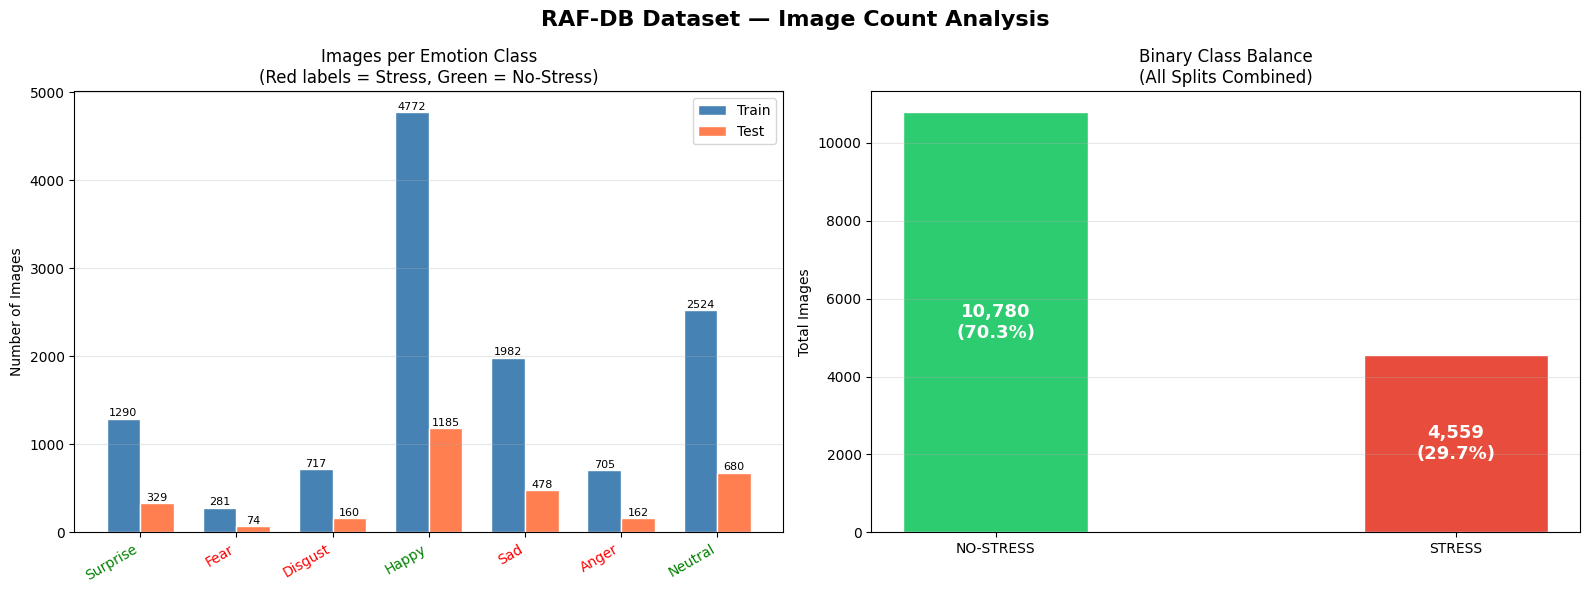

✅  RAF-DB distribution chart saved!


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RAF-DB Dataset — Image Count Analysis', fontsize=16, fontweight='bold')

# ── Plot 1: Per-emotion count (stacked by train/test) ────────
train_data = raf_df[raf_df['Split'] == 'Train'].set_index('Emotion')['Image Count']
test_data  = raf_df[raf_df['Split'] == 'Test'].set_index('Emotion')['Image Count']

emotions = [RAF_EMOTION_NAMES[str(i)] for i in range(1, 8)]

x = np.arange(len(emotions))
width = 0.35

bars1 = axes[0].bar(x - width/2, [train_data.get(e, 0) for e in emotions],
                    width, label='Train', color='steelblue', edgecolor='white')
bars2 = axes[0].bar(x + width/2, [test_data.get(e, 0) for e in emotions],
                    width, label='Test',  color='coral',     edgecolor='white')

# Colour the x-tick labels by stress/no-stress
tick_colours = ['red' if RAF_EMOTION_NAMES[str(i)] in
                [RAF_EMOTION_NAMES[k] for k in RAF_STRESS_FOLDERS] else 'green'
                for i in range(1, 8)]

axes[0].set_xticks(x)
axes[0].set_xticklabels(emotions, rotation=30, ha='right')
for tick, colour in zip(axes[0].get_xticklabels(), tick_colours):
    tick.set_color(colour)

axes[0].set_title('Images per Emotion Class\n(Red labels = Stress, Green = No-Stress)',
                  fontsize=12)
axes[0].set_ylabel('Number of Images')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on top of bars
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 5,
                 str(int(h)), ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 5,
                 str(int(h)), ha='center', va='bottom', fontsize=8)

# ── Plot 2: Binary class balance (Stress vs No-Stress) ───────
binary_totals = raf_df.groupby('Label Name')['Image Count'].sum()

colours = ['#e74c3c' if lbl == 'STRESS' else '#2ecc71'
           for lbl in binary_totals.index]

bars3 = axes[1].bar(binary_totals.index, binary_totals.values,
                    color=colours, edgecolor='white', width=0.4)

# Add percentage labels inside bars
total_imgs = binary_totals.sum()
for bar, val in zip(bars3, binary_totals.values):
    pct = val / total_imgs * 100
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() / 2,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', va='center',
                 fontsize=13, fontweight='bold', color='white')

axes[1].set_title('Binary Class Balance\n(All Splits Combined)', fontsize=12)
axes[1].set_ylabel('Total Images')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/raf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  RAF-DB distribution chart saved!")


In [35]:
print("  📊  EDA — CK+ DATASET CSV ANALYSIS")


  📊  EDA — CK+ DATASET CSV ANALYSIS


In [36]:
ck_df = pd.read_csv(CK_CSV_PATH)


In [39]:
print(ck_df.shape)

(920, 3)


In [44]:
print(list(ck_df.columns))


['emotion', 'pixels', 'Usage']


In [45]:
print(ck_df.head())


   emotion                                             pixels     Usage
0        6  36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...  Training
1        6  88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...  Training
2        6  9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...  Training
3        6  104 106 108 104 95 50 60 61 58 83 126 133 139 ...  Training
4        6  68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...  Training


In [46]:
print(ck_df.tail())


     emotion                                             pixels        Usage
915        5  87 86 88 92 92 127 231 248 251 253 254 254 254...  PrivateTest
916        5  21 24 26 28 27 28 30 8 0 0 0 0 0 0 1 4 37 42 4...  PrivateTest
917        5  76 40 31 38 28 34 38 36 41 36 46 38 44 26 45 5...  PrivateTest
918        5  114 87 16 29 17 25 30 34 37 35 45 93 63 80 73 ...  PrivateTest
919        5  101 102 99 96 98 42 23 18 15 17 27 34 17 24 29...  PrivateTest


In [47]:
print(ck_df.dtypes)


emotion     int64
pixels     object
Usage      object
dtype: object


In [50]:
missing = ck_df.isnull().sum()
print(missing)


emotion    0
pixels     0
Usage      0
dtype: int64


In [52]:
total_missing = ck_df.isnull().sum().sum()
if total_missing == 0:
    print("No missing values — clean dataset!")
else:
    print(f"{total_missing} missing values found — will drop them.")


No missing values — clean dataset!


In [53]:
print(ck_df.describe())


          emotion
count  920.000000
mean     4.920652
std      1.882630
min      0.000000
25%      5.000000
50%      6.000000
75%      6.000000
max      7.000000


In [54]:
ck_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  920 non-null    int64 
 1   pixels   920 non-null    object
 2   Usage    920 non-null    object
dtypes: int64(1), object(2)
memory usage: 21.7+ KB


In [55]:
print(ck_df['Usage'].unique())


['Training' 'PublicTest' 'PrivateTest']


In [56]:
print(ck_df['Usage'].value_counts())


Usage
Training       734
PrivateTest     95
PublicTest      91
Name: count, dtype: int64


In [57]:
emotion_counts = ck_df['emotion'].value_counts().sort_index()
print(emotion_counts)

emotion
0     45
1     59
2     25
3     69
4     28
5     83
6    593
7     18
Name: count, dtype: int64


In [58]:
emotion_count_df = pd.DataFrame({
    'Emotion Code' : emotion_counts.index,
    'Emotion Name' : [CK_EMOTION_NAMES.get(i, 'Unknown') for i in emotion_counts.index],
    'Frame Count'  : emotion_counts.values,
    'Stress Label' : ['STRESS' if i in CK_STRESS_EMOTIONS else 'NO-STRESS'
                      for i in emotion_counts.index],
})
print("\n📋  Emotion table with labels:")
print(emotion_count_df.to_string(index=False))


📋  Emotion table with labels:
 Emotion Code Emotion Name  Frame Count Stress Label
            0        Anger           45       STRESS
            1     Contempt           59    NO-STRESS
            2      Disgust           25       STRESS
            3         Fear           69       STRESS
            4        Happy           28    NO-STRESS
            5      Sadness           83       STRESS
            6     Surprise          593    NO-STRESS
            7      Neutral           18    NO-STRESS


In [60]:
# we dont print the large pixel values instead just the emotion label i.e metadata columns you want to inspect
cols_to_show = [c for c in ck_df.columns if c != 'pixels']
print(ck_df[cols_to_show].sample(3, random_state=SEED))

     emotion        Usage
319        6     Training
377        6     Training
538        6  PrivateTest


In [64]:
print("\n Pixel string format check:")

# we get first row's pixel string i.e 2404 space seperated integers (0-255 range)
sample_pixel_str = ck_df['pixels'].iloc[0]

# convert into list form. splitting by space
#each value = one pixel intensity (grayscale)
pixel_values     = sample_pixel_str.split(' ')

print(f"Pixel string length (chars): {len(sample_pixel_str)}") #pixel string length that has spaces too (before splitting)
print(f"Number of pixel values     : {len(pixel_values)}")
print(f"First 10 pixel values      : {pixel_values[:10]}")
print(f"Expected: 48×48 = 2304 pixel values → Got: {len(pixel_values)}")


 Pixel string format check:
Pixel string length (chars): 8036
Number of pixel values     : 2304
First 10 pixel values      : ['36', '39', '35', '25', '19', '11', '8', '7', '3', '13']
Expected: 48×48 = 2304 pixel values → Got: 2304


In [65]:
if len(pixel_values) == 2304:
    print("Pixel format is correct (48×48 = 2304 values)")
else:
    print("Unexpected pixel count! Check the CSV.")

Pixel format is correct (48×48 = 2304 values)


In [67]:
#Filter to only rows with valid emotion numbers
valid_emotions = set(CK_EMOTION_NAMES.keys())          # 0 through 7
invalid_rows   = ck_df[~ck_df['emotion'].isin(valid_emotions)]
print(f"\nRows with invalid emotion codes: {len(invalid_rows)}")


Rows with invalid emotion codes: 0


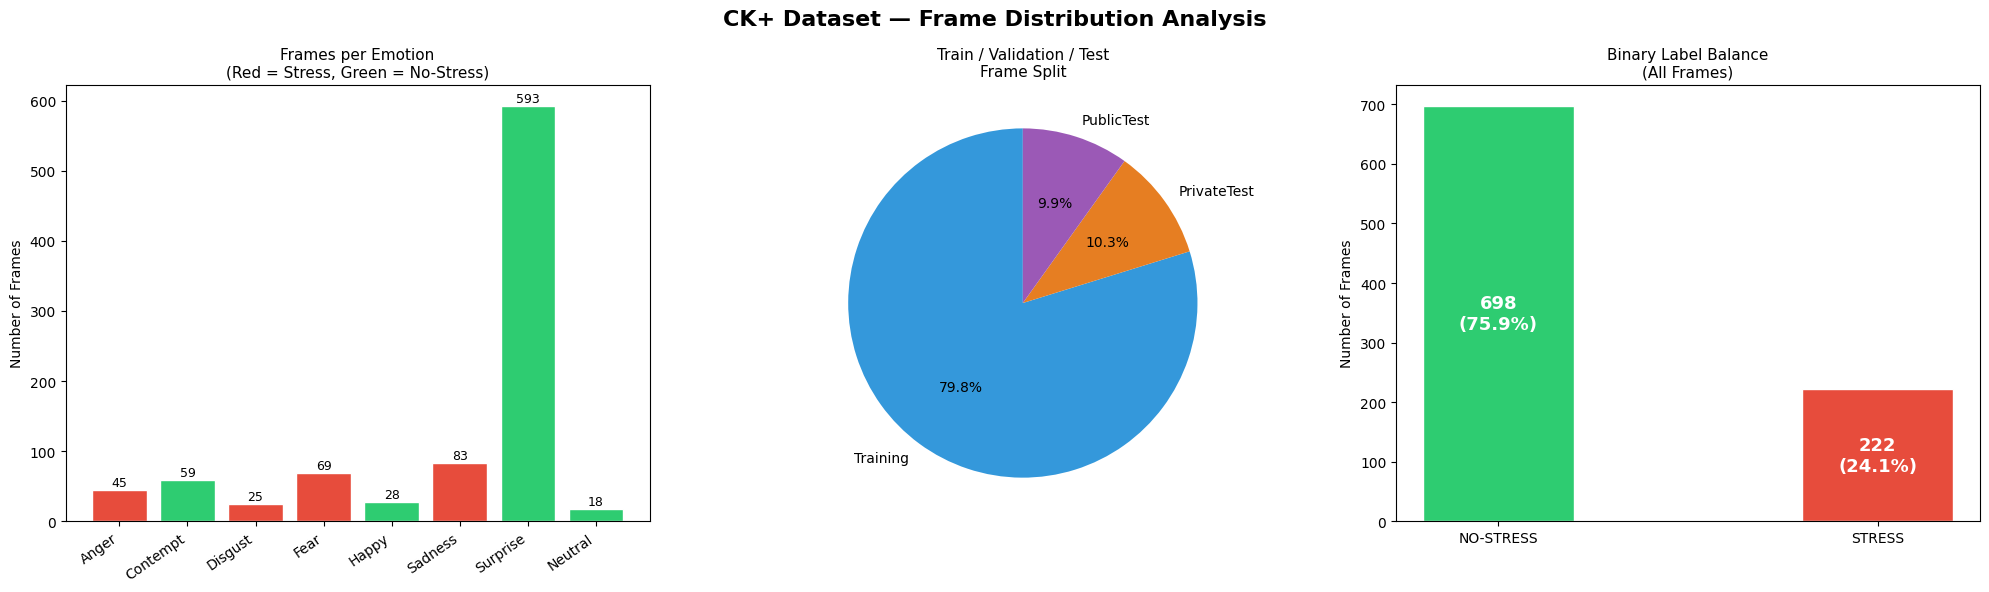

✅  CK+ distribution chart saved!


In [69]:
# EDA VISUALIZATION FOR CK+ DISTRIBUTIONS

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('CK+ Dataset — Frame Distribution Analysis', fontsize=16, fontweight='bold')

# Plot 1: Frame count per emotion
emotion_names_list = [CK_EMOTION_NAMES[i] for i in sorted(emotion_counts.index)]
frame_counts_list  = [emotion_counts[i]   for i in sorted(emotion_counts.index)]

bar_colours = ['#e74c3c' if i in CK_STRESS_EMOTIONS else '#2ecc71'
               for i in sorted(emotion_counts.index)]

bars = axes[0].bar(emotion_names_list, frame_counts_list, color=bar_colours, edgecolor='white')
axes[0].set_title('Frames per Emotion\n(Red = Stress, Green = No-Stress)', fontsize=11)
axes[0].set_ylabel('Number of Frames')

# FIXED: Set ticks FIRST, then labels
axes[0].set_xticks(range(len(emotion_names_list)))
axes[0].set_xticklabels(emotion_names_list, rotation=35, ha='right')

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=9)

# Plot 2: Train vs Test split
usage_counts = ck_df['Usage'].value_counts()
axes[1].pie(usage_counts.values,
            labels=usage_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=['#3498db', '#e67e22', '#9b59b6'])
axes[1].set_title('Train / Validation / Test\nFrame Split', fontsize=11)

# Plot 3: Binary Stress vs No-Stress balance
stress_count    = ck_df[ck_df['emotion'].isin(CK_STRESS_EMOTIONS)].shape[0]
no_stress_count = ck_df[~ck_df['emotion'].isin(CK_STRESS_EMOTIONS)].shape[0]

axes[2].bar(['NO-STRESS', 'STRESS'],
            [no_stress_count, stress_count],
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.4)

total = stress_count + no_stress_count
for i, (label, val) in enumerate(zip(['NO-STRESS', 'STRESS'],
                                      [no_stress_count, stress_count])):
    axes[2].text(i, val / 2,
                 f'{val:,}\n({val/total*100:.1f}%)',
                 ha='center', va='center',
                 fontsize=13, fontweight='bold', color='white')

axes[2].set_title('Binary Label Balance\n(All Frames)', fontsize=11)
axes[2].set_ylabel('Number of Frames')

plt.tight_layout()
plt.savefig('/content/ckplus_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  CK+ distribution chart saved!")
